Kütüphane ve Veri Yükleme


In [2]:
import numpy as np 
import pandas as pd 
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

df = pd.read_csv("../../data/raw/company_esg_financial_dataset.csv")
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


eksik degerleri medyan ile doldur.

In [3]:

# ----------------------------------------------------------------------
# NaN değerlerini doldurma işlemi
# ----------------------------------------------------------------------

# 'CompanyID' sütununa göre gruplama yapılır.
# transform() metodu ile her bir şirketin GrowthRate medyanı hesaplanır.
# fillna() ile NaN değerler bu medyan ile doldurulur.
df['GrowthRate'] = df.groupby('CompanyID')['GrowthRate'].transform(lambda x: x.fillna(x.median()))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         11000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [16]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
df['NewCompanyName']=le.fit_transform(df.CompanyName)
df.head()

df.describe()


,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption,NewCompanyName
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04,11000.000000
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.831100,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07,499.500000
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.189006,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07,288.688113
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03,0.000000
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.100000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05,249.750000
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06,499.500000
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,10.800000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06,749.250000
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09,999.000000


In [17]:
from matplotlib import pyplot as plt
import seaborn as sns

col = df.columns

col

Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue',
       'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption', 'NewCompanyName'],
      dtype='object')

TREND VE KÜMELEME

--- Trend Analizi Başlıyor ---


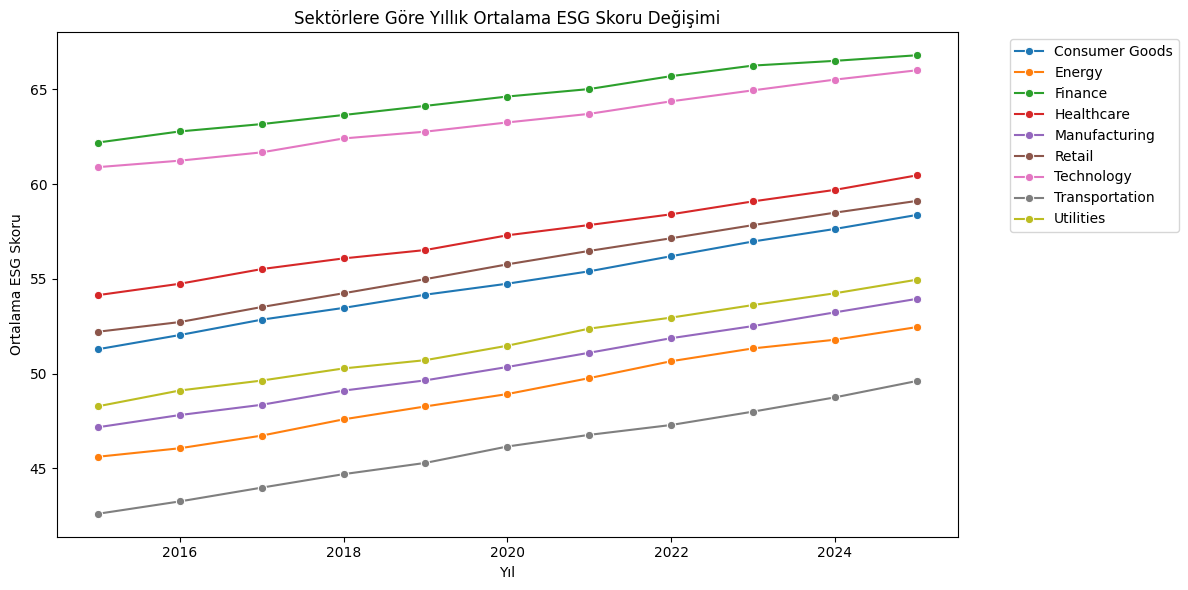

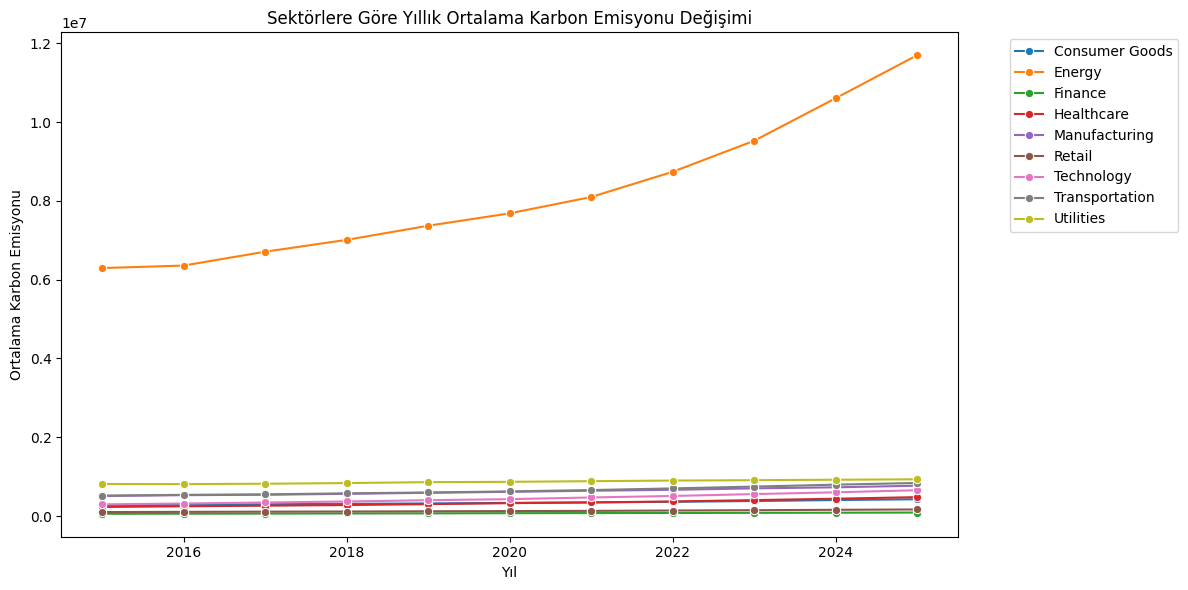

--- Kümeleme Analizi Başlıyor ---

Küme Özetleri (Ortalama Değerler):
              Revenue  ProfitMargin  ESG_Overall
Cluster                                         
0         5884.620749     20.742659    59.912294
1         3055.064966      5.631973    65.906792
2         2498.874162      8.044072    39.386368
3        66136.521910     13.956180    68.147753


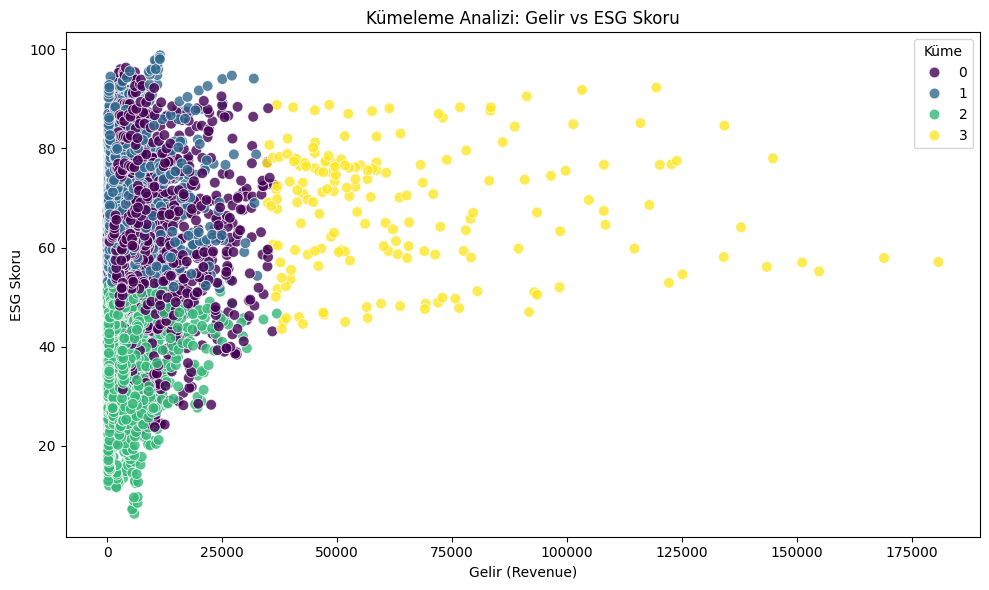

--- Tüm analizler tamamlandı. ---


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# 3. SEÇENEK B: TREND ANALİZİ (Zaman Serisi)
# ---------------------------------------------------------
print("--- Trend Analizi Başlıyor ---")

# Yıl ve Sektöre göre ortalamaları al
trend_data = df.groupby(['Year', 'Industry'])[['ESG_Overall', 'Revenue', 'CarbonEmissions']].mean().reset_index()

# Grafik 1: Yıllara Göre ESG Skoru Değişimi
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='Year', y='ESG_Overall', hue='Industry', marker='o')
plt.title('Sektörlere Göre Yıllık Ortalama ESG Skoru Değişimi')
plt.ylabel('Ortalama ESG Skoru')
plt.xlabel('Yıl')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Grafik 2: Yıllara Göre Karbon Emisyonu Değişimi
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='Year', y='CarbonEmissions', hue='Industry', marker='o')
plt.title('Sektörlere Göre Yıllık Ortalama Karbon Emisyonu Değişimi')
plt.ylabel('Ortalama Karbon Emisyonu')
plt.xlabel('Yıl')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 4. SEÇENEK C: KÜMELEME ANALİZİ (K-Means Clustering)
# ---------------------------------------------------------
print("--- Kümeleme Analizi Başlıyor ---")
df_clean = df.dropna().copy()  # Eksik verileri temizle
# Kümeleme için kullanılacak özellikleri seç (Gelir, Kâr Marjı, ESG Skoru)
features = ['Revenue', 'ProfitMargin', 'ESG_Overall']
X = df_clean[features]

# Veriyi ölçeklendir (Standartlaştırma - Clustering için çok önemlidir)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means modelini kur (4 küme olarak ayarladık)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Kümeleri tahmin et ve veri setine ekle
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# Küme merkezlerini (karakteristiklerini) ekrana yazdır
cluster_summary = df_clean.groupby('Cluster')[features].mean()
print("\nKüme Özetleri (Ortalama Değerler):")
print(cluster_summary)

# Kümeleri Görselleştir (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Revenue', y='ESG_Overall', hue='Cluster', palette='viridis', alpha=0.8, s=60)
plt.title('Kümeleme Analizi: Gelir vs ESG Skoru')
plt.xlabel('Gelir (Revenue)')
plt.ylabel('ESG Skoru')
plt.legend(title='Küme')
plt.tight_layout()
plt.show()

# Sonuçları kaydetmek isterseniz:
# df_clean.to_csv('sirket_analiz_sonuclari.csv', index=False)
print("--- Tüm analizler tamamlandı. ---")

   Veri temizlendi. Analize hazır.
2. Kümeleme (Clustering) yapılıyor...
   'Cluster' sütunu başarıyla oluşturuldu!
3. Başarı faktörleri analiz ediliyor...


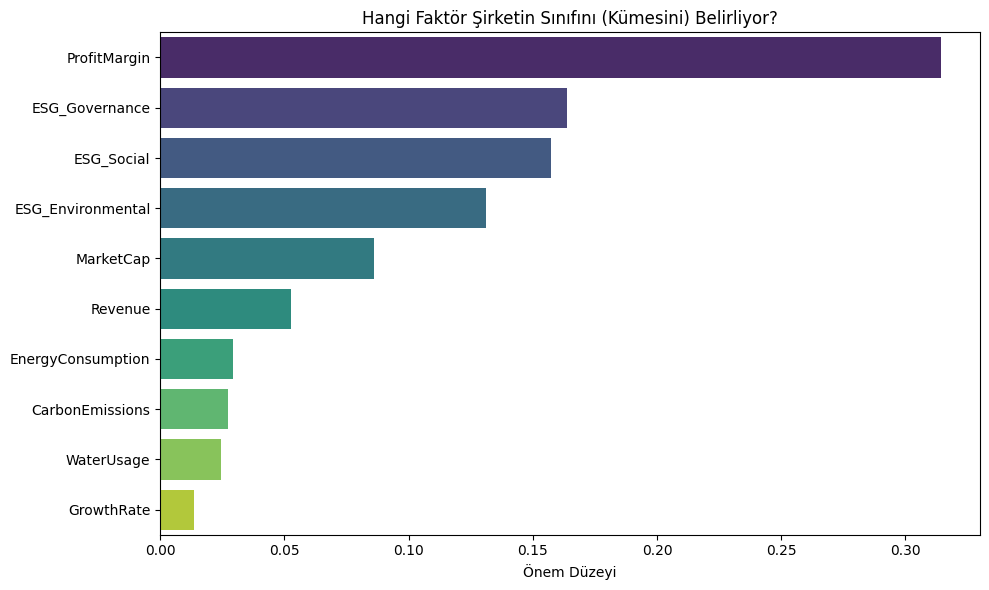

4. Büyüme tahmin modeli çalıştırılıyor...
   Büyüme Tahmini Ortalama Hata Payı (MAE): 33.44
5. Simülasyon senaryosu çalıştırılıyor...
   Seçilen Şirket: Company_4 (Mevcut Küme: 0)
   Simülasyon Sonucu (Yeni Küme Tahmini): 0
   Yorum: Şirket sınıf değiştiremedi. Finansal veriler baskın geldi.

--- TÜM İŞLEMLER BAŞARIYLA TAMAMLANDI ---


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_absolute_error

# =============================================================================
# 1. VERİ YÜKLEME VE HAZIRLIK (Sıfırdan Başlatıyoruz)
# =============================================================================

# Eksik verileri temizle
df_clean = df.dropna().copy()
print("   Veri temizlendi. Analize hazır.")

# =============================================================================
# 2. KRİTİK ADIM: KÜMELEME (Cluster Sütununu Bu Adım Oluşturur!)
# =============================================================================
print("2. Kümeleme (Clustering) yapılıyor...")

# Kümeleme için kullanılacak sütunlar
cluster_features = ['Revenue', 'ProfitMargin', 'ESG_Overall']

# Veriyi ölçeklendir
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_clean[cluster_features])

# K-Means modelini kur ve 'Cluster' sütununu oluştur
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_cluster)

print("   'Cluster' sütunu başarıyla oluşturuldu!")

# =============================================================================
# 3. ANALİZ: BAŞARI FAKTÖRLERİ (Feature Importance)
# =============================================================================
print("3. Başarı faktörleri analiz ediliyor...")

feature_cols = ['Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 
                'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 
                'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

# Artık 'Cluster' sütunu var olduğu için bu satır hata vermeyecek:
X_cls = df_clean[feature_cols]
y_cls = df_clean['Cluster']

# Modeli eğit
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_cls, y_cls)

# Sonuçları Görselleştir
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[feature_cols[i] for i in indices], palette="viridis")
plt.title("Hangi Faktör Şirketin Sınıfını (Kümesini) Belirliyor?")
plt.xlabel("Önem Düzeyi")
plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALİZ: GELECEK TAHMİNİ (Büyüme Oranı)
# =============================================================================
print("4. Büyüme tahmin modeli çalıştırılıyor...")

# Hedef: Revenue
predict_features = ['Revenue', 'ProfitMargin', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions']
X_reg = df_clean[predict_features]
y_reg = df_clean['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

mae = mean_absolute_error(y_test, rf_reg.predict(X_test))
print(f"   Büyüme Tahmini Ortalama Hata Payı (MAE): {mae:.2f}")

# =============================================================================
# 5. ANALİZ: SİMÜLASYON (What-If)
# =============================================================================
print("5. Simülasyon senaryosu çalıştırılıyor...")

# Riskli gruptan (Cluster 0) bir şirket seç
sample_company = df_clean[df_clean['Cluster'] == 0].iloc[0].copy()
print(f"   Seçilen Şirket: {sample_company['CompanyName']} (Mevcut Küme: {sample_company['Cluster']})")

# Senaryo: Çevresel Skoru %20 artır, Emisyonu %20 azalt
modified_company = sample_company.copy()
modified_company['ESG_Environmental'] *= 1.20
modified_company['CarbonEmissions'] *= 0.80

# Yeni durumu tahmin et
modified_data = modified_company[feature_cols].values.reshape(1, -1)
new_pred = rf_clf.predict(modified_data)[0]

print(f"   Simülasyon Sonucu (Yeni Küme Tahmini): {new_pred}")

if new_pred == sample_company['Cluster']:
    print("   Yorum: Şirket sınıf değiştiremedi. Finansal veriler baskın geldi.")
else:
    print("   Yorum: Şirket sınıf atladı!")

print("\n--- TÜM İŞLEMLER BAŞARIYLA TAMAMLANDI ---")

MODEL

--- 1. Veri Hazırlanıyor ve Özellikler Türetiliyor ---

--- 2. Modeller Yarıştırılıyor (Validasyon: 2025 Yılı) ---
Linear Regression -> Hata Payı (MAE): 315.40 | Başarı Skoru (R2): 0.9972
Random Forest -> Hata Payı (MAE): 415.58 | Başarı Skoru (R2): 0.9860
Gradient Boosting -> Hata Payı (MAE): 414.52 | Başarı Skoru (R2): 0.9882

>>> KAZANAN MODEL: Linear Regression (En Düşük Hata)

--- 3. 2026 Yılı Tahmin Ediliyor (Linear Regression ile) ---


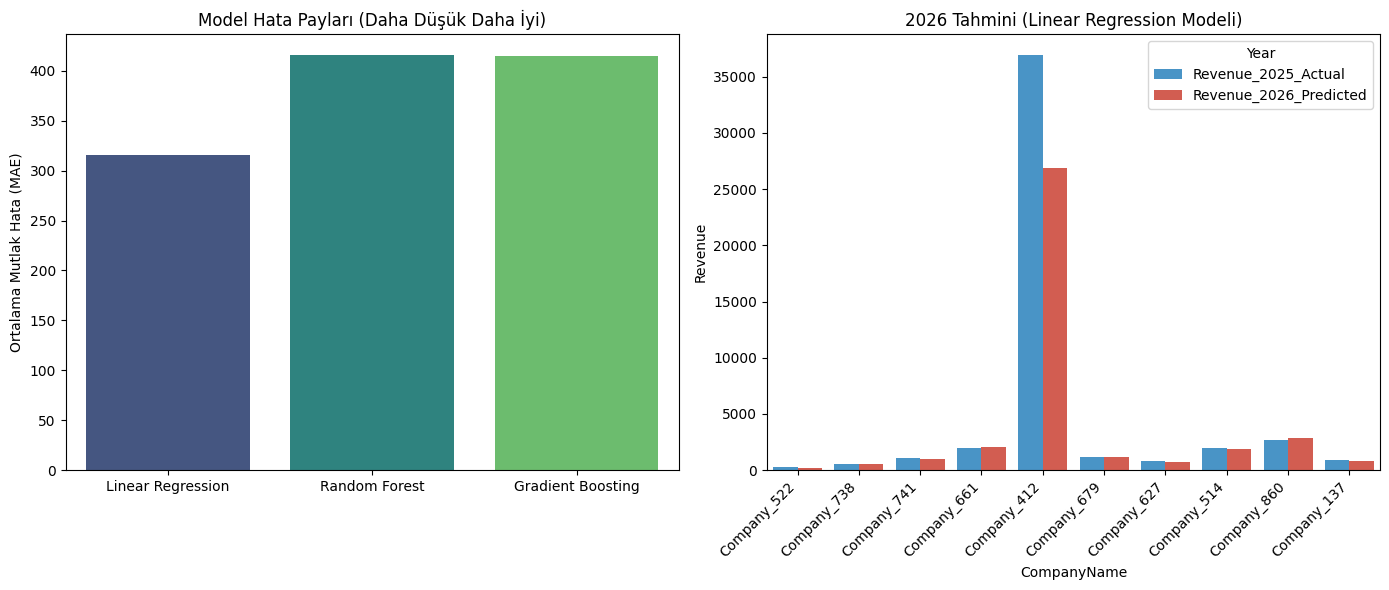


--- EN ÇOK BÜYÜMESİ BEKLENEN 5 ŞİRKET ---
       CompanyName       Industry  Growth_Percent
10240  Company_931         Energy       47.120457
2045   Company_186  Manufacturing       46.341413
7160   Company_651         Energy       46.043921
3761   Company_342         Energy       39.472547
4993   Company_454  Manufacturing       39.392361

Detaylı sonuçlar '2026_coklu_model_tahminleri.csv' dosyasına kaydedildi.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. VERİ YÜKLEME VE ÖZELLİK MÜHENDİSLİĞİ (Feature Engineering)
# -----------------------------------------------------------------------------
print("--- 1. Veri Hazırlanıyor ve Özellikler Türetiliyor ---")
df_clean = df.dropna().copy()
df_clean = df_clean.sort_values(by=['CompanyID', 'Year'])

# Modele "zamanı" öğreten kritik değişkenler
# Bir önceki yılın geliri (Lag1)
df_clean['Revenue_Lag1'] = df_clean.groupby('CompanyID')['Revenue'].shift(1)
# Son 3 yılın ortalama geliri (Trend)
df_clean['Revenue_Rolling3'] = df_clean.groupby('CompanyID')['Revenue'].transform(lambda x: x.rolling(window=3).mean())
# Bir önceki yılın kar marjı (Lag1) - Geleceği tahmin ederken geçmiş kar marjını kullanmak daha gerçekçi
df_clean['ProfitMargin_Lag1'] = df_clean.groupby('CompanyID')['ProfitMargin'].shift(1)

# İlk yıllardaki eksik verileri temizle
df_model = df_clean.dropna()

# 2. MODEL VALIDASYONU (2025 Yılını Test Olarak Ayırma)
# -----------------------------------------------------------------------------
print("\n--- 2. Modeller Yarıştırılıyor (Validasyon: 2025 Yılı) ---")

# Eğitim Seti: 2024 ve öncesi
train_data = df_model[df_model['Year'] < 2025]
# Test Seti: Sadece 2025 (Modelin hiç görmediği veri)
test_data = df_model[df_model['Year'] == 2025]

# Model Girdileri
features = ['Revenue_Lag1', 'Revenue_Rolling3', 'ProfitMargin_Lag1', 
            'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'Year']

# Kategorik verileri (Industry, Region) ekle
X_train = pd.get_dummies(train_data[features + ['Industry', 'Region']], drop_first=True)
y_train = train_data['Revenue']

# Test verisinin sütunlarını eğitim verisiyle eşitle (Reindexing)
X_test = pd.get_dummies(test_data[features + ['Industry', 'Region']], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = test_data['Revenue']

# Kullanılacak Modeller
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    # Modeli Eğit
    model.fit(X_train, y_train)
    # Tahmin Et
    y_pred = model.predict(X_test)
    # Performansı Ölç
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "R2": r2, "Model": model}
    print(f"{name} -> Hata Payı (MAE): {mae:.2f} | Başarı Skoru (R2): {r2:.4f}")

# En iyi modeli seç (En düşük MAE)
best_model_name = min(results, key=lambda x: results[x]['MAE'])
best_model = results[best_model_name]['Model']
print(f"\n>>> KAZANAN MODEL: {best_model_name} (En Düşük Hata)")


# 3. 2026 GELECEK TAHMİNİ (En İyi Model İle)
# -----------------------------------------------------------------------------
print(f"\n--- 3. 2026 Yılı Tahmin Ediliyor ({best_model_name} ile) ---")

# 2026 tahmininin girdisi 2025 verileridir
df_2025 = df_clean[df_clean['Year'] == 2025].copy()
df_2025['Revenue_Lag1'] = df_2025['Revenue'] # 2025 geliri, 2026'nın Lag1'idir
df_2025['ProfitMargin_Lag1'] = df_2025['ProfitMargin']
# Rolling3 olduğu gibi kalır veya güncellenir (Burada basitlik için mevcut bırakıyoruz)
df_2025['Year'] = 2026

# Girdileri hazırla
X_future = pd.get_dummies(df_2025[features + ['Industry', 'Region']], drop_first=True)
X_future = X_future.reindex(columns=X_train.columns, fill_value=0)

# Tüm verilerle (2015-2025) en iyi modeli tekrar eğit (Maksimum bilgi için)
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])
best_model.fit(X_all, y_all)

# 2026 Tahminini Yap
predictions_2026 = best_model.predict(X_future)

# Sonuçları Kaydet
final_df = df_2025[['CompanyID', 'CompanyName', 'Industry', 'Region']].copy()
final_df['Revenue_2025_Actual'] = df_2025['Revenue']
final_df['Revenue_2026_Predicted'] = predictions_2026
final_df['Growth_Percent'] = ((final_df['Revenue_2026_Predicted'] - final_df['Revenue_2025_Actual']) / final_df['Revenue_2025_Actual']) * 100

# 4. GÖRSELLEŞTİRME
# -----------------------------------------------------------------------------
plt.figure(figsize=(14, 6))

# Grafik 1: Model Performans Karşılaştırması
plt.subplot(1, 2, 1)
mae_values = [res['MAE'] for res in results.values()]
model_names = list(results.keys())
sns.barplot(x=model_names, y=mae_values, palette="viridis")
plt.title("Model Hata Payları (Daha Düşük Daha İyi)")
plt.ylabel("Ortalama Mutlak Hata (MAE)")

# Grafik 2: 2026 Tahminleri (Rastgele 10 Şirket)
plt.subplot(1, 2, 2)
sample_companies = final_df.sample(10, random_state=42)
plot_data = sample_companies.melt(id_vars=['CompanyName'], value_vars=['Revenue_2025_Actual', 'Revenue_2026_Predicted'], var_name='Year', value_name='Revenue')
sns.barplot(data=plot_data, x='CompanyName', y='Revenue', hue='Year', palette=['#3498db', '#e74c3c'])
plt.title(f"2026 Tahmini ({best_model_name} Modeli)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Sonuçları Yazdır
print("\n--- EN ÇOK BÜYÜMESİ BEKLENEN 5 ŞİRKET ---")
print(final_df.sort_values('Growth_Percent', ascending=False)[['CompanyName', 'Industry', 'Growth_Percent']].head(5))

final_df.to_csv('2026_coklu_model_tahminleri.csv', index=False)
print("\nDetaylı sonuçlar '2026_coklu_model_tahminleri.csv' dosyasına kaydedildi.")